In [307]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [308]:
df=pd.read_csv("credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [309]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [310]:
df.size

390972

In [311]:
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [312]:
df = df.dropna(subset=['loan_int_rate', 'person_emp_length'])

In [313]:
df.isna().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [314]:
df.duplicated().sum()

np.int64(137)

In [315]:
df = df.drop_duplicates()

In [316]:
df.duplicated().sum()

np.int64(0)

In [317]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [318]:
df['loan_to_credit_hist'] = df['loan_amnt'] / (df['cb_person_cred_hist_length'] + 1)
df['working_start_age'] = df['person_age'] - df['person_emp_length']
df['interest_burden'] = df['loan_amnt'] * df['loan_int_rate']
df['default_flag'] = df['cb_person_default_on_file'].map({'Y':1, 'N':0})

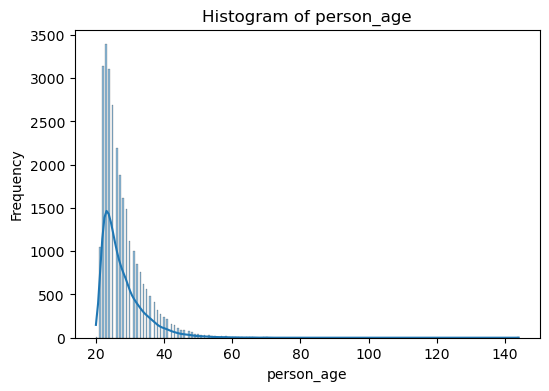

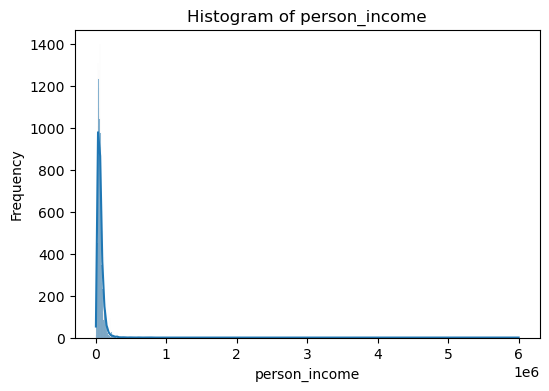

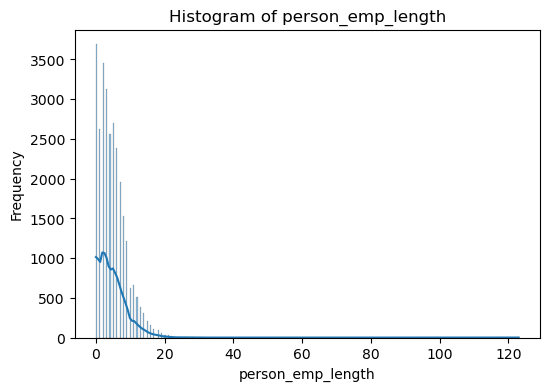

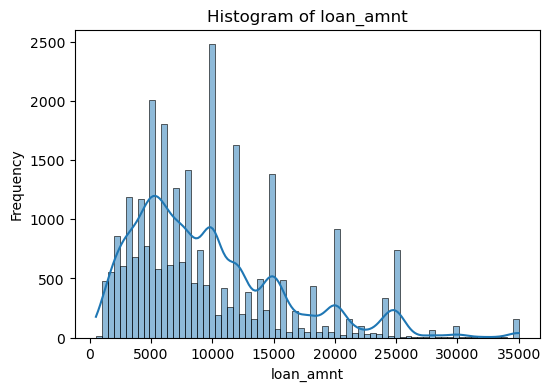

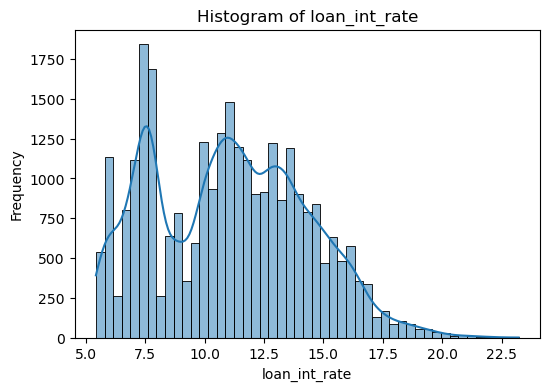

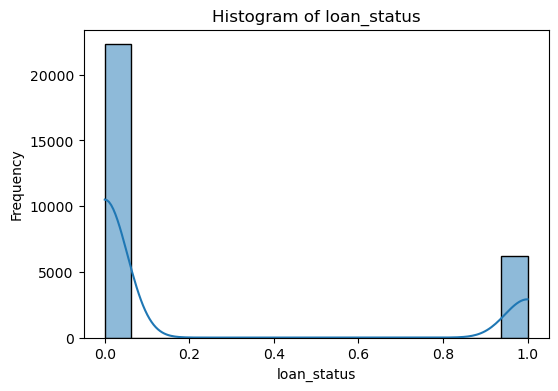

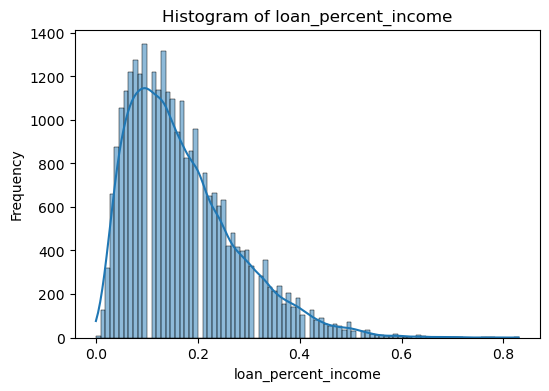

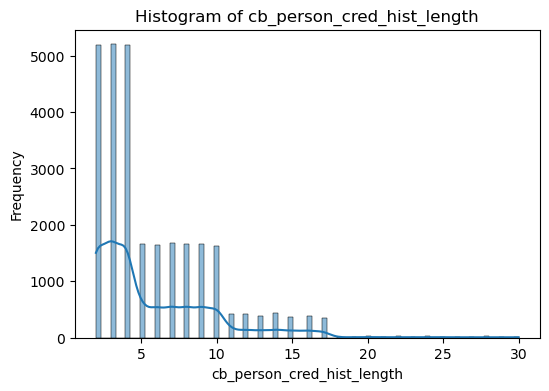

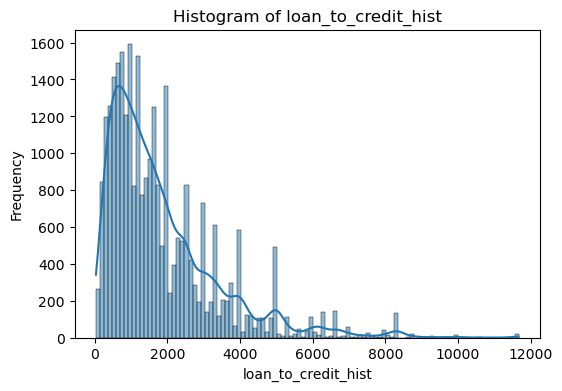

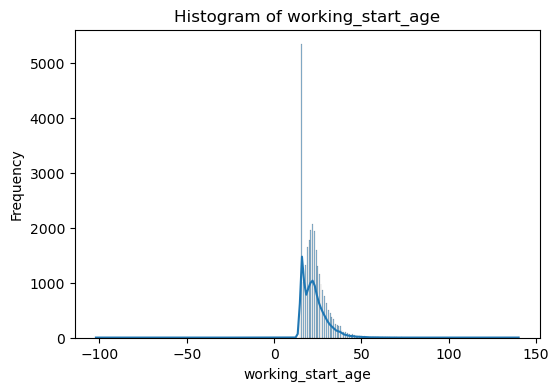

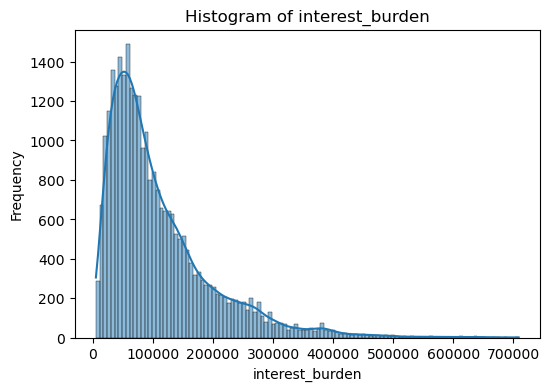

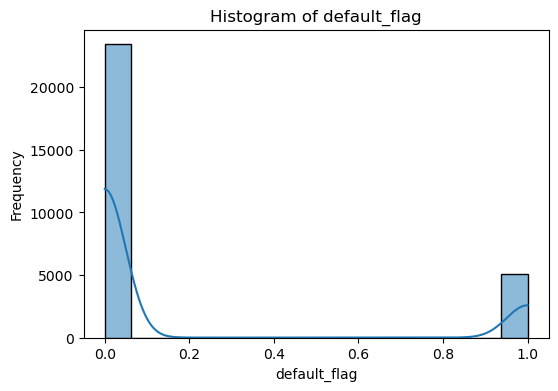

In [319]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Histplot for each numerical column
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

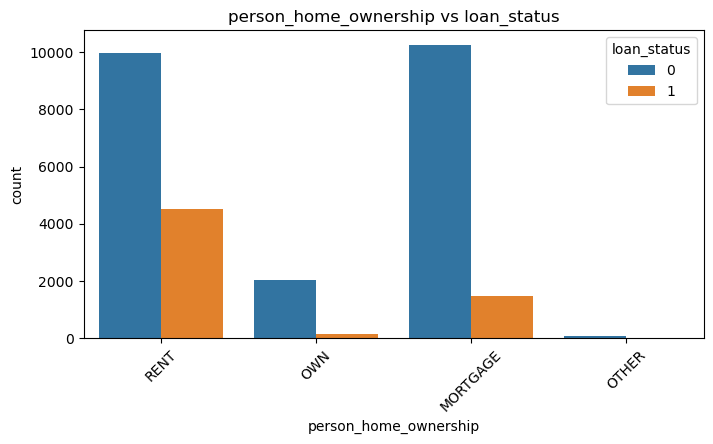

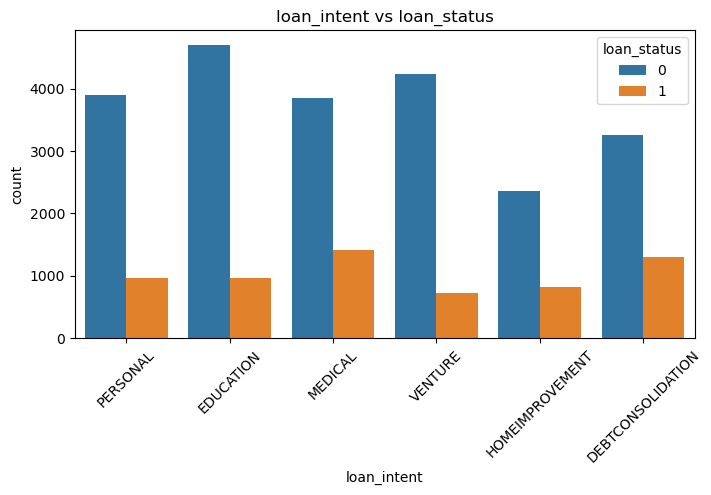

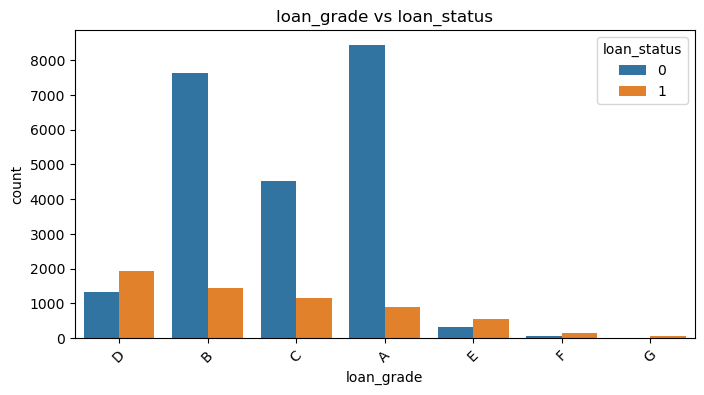

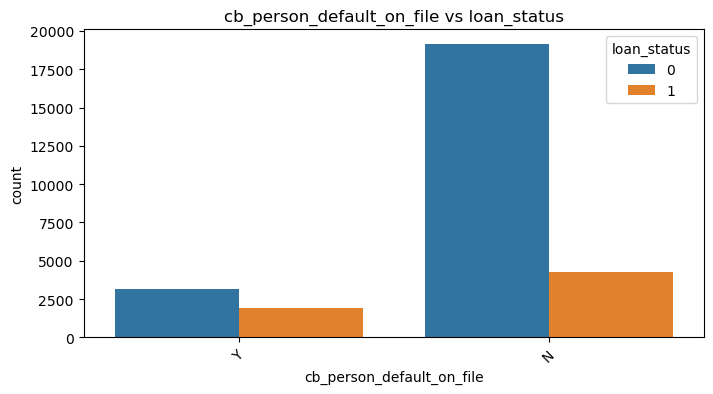

In [320]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    if col != 'loan_status':
        plt.figure(figsize=(8, 4))
        sns.countplot(data=df, x=col, hue='loan_status')
        plt.title(f'{col} vs loan_status')
        plt.xticks(rotation=45)
        plt.show()


In [321]:
print(df[['person_age', 'person_income', 'person_emp_length']].skew())

person_age            2.563895
person_income        35.302717
person_emp_length     2.758044
dtype: float64


In [322]:
import numpy as np

cols = ['person_age', 'person_income']

for col in cols:
    df[col] = np.log1p(df[col])

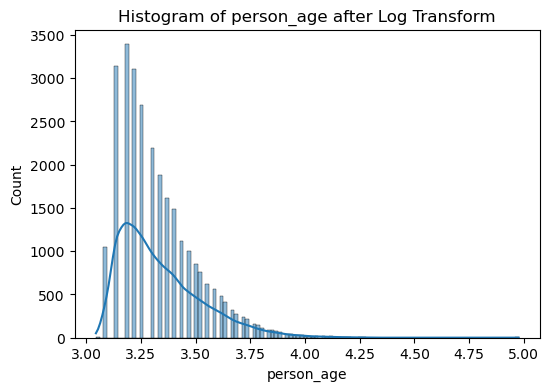

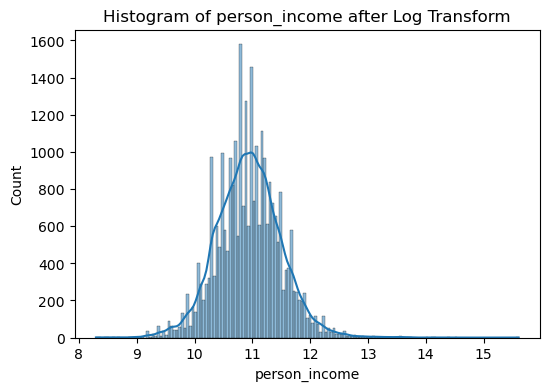

In [323]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col} after Log Transform')
    plt.show()

In [324]:
df.drop("person_age",axis=1,inplace=True)

In [325]:
df.corr(numeric_only=True)

,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,loan_to_credit_hist,working_start_age,interest_burden,default_flag
person_income,1.000000,0.213656,0.423047,-0.026027,-0.273517,-0.376386,0.100870,0.265204,-0.010233,0.358062,-0.018489
person_emp_length,0.213656,1.000000,0.110934,-0.056607,-0.082852,-0.055033,0.146486,0.000624,-0.446856,0.075610,-0.028179
loan_amnt,0.423047,0.110934,1.000000,0.146026,0.114153,0.577708,0.045334,0.745209,-0.017030,0.903683,0.040714
loan_int_rate,-0.026027,-0.056607,0.146026,1.000000,0.339995,0.123441,0.014562,0.105797,0.043026,0.482727,0.500174
loan_status,-0.273517,-0.082852,0.114153,0.339995,1.000000,0.380000,-0.016559,0.102732,0.027618,0.222743,0.182397
loan_percent_income,-0.376386,-0.055033,0.577708,0.123441,0.380000,1.000000,-0.029690,0.480986,-0.004134,0.523099,0.036503
cb_person_cred_hist_length,0.100870,0.146486,0.045334,0.014562,-0.016559,-0.029690,1.000000,-0.451359,0.692325,0.043020,0.007988
loan_to_credit_hist,0.265204,0.000624,0.745209,0.105797,0.102732,0.480986,-0.451359,1.000000,-0.323690,0.670665,0.025399
working_start_age,-0.010233,-0.446856,-0.017030,0.043026,0.027618,-0.004134,0.692325,-0.323690,1.000000,-0.000558,0.023340
interest_burden,0.358062,0.075610,0.903683,0.482727,0.222743,0.523099,0.043020,0.670665,-0.000558,1.000000,0.214262


In [326]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Label Encoding
le = LabelEncoder()

df['cb_person_default_on_file'] = le.fit_transform(df['cb_person_default_on_file'])
df['loan_status'] = le.fit_transform(df['loan_status'])

# Object columns for One-Hot Encoding
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Remove already encoded column
if 'cb_person_default_on_file' in cat_cols:
    cat_cols.remove('cb_person_default_on_file')

# One-Hot Encoding with integer output
df = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

print(df.head())
print(df.dtypes)

   person_income  person_emp_length  loan_amnt  loan_int_rate  loan_status  \
0      10.985310              123.0      35000          16.02            1   
1       9.169623                5.0       1000          11.14            0   
2       9.169623                1.0       5500          12.87            1   
3      11.089821                4.0      35000          15.23            1   
4      10.904138                8.0      35000          14.27            1   

   loan_percent_income  cb_person_default_on_file  cb_person_cred_hist_length  \
0                 0.59                          1                           3   
1                 0.10                          0                           2   
2                 0.57                          0                           3   
3                 0.53                          0                           2   
4                 0.55                          1                           4   

   loan_to_credit_hist  working_start_age  .

In [327]:
df.head()

,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_credit_hist,working_start_age,...,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
0,10.985310,123.0,35000,16.02,1,0.59,1,3,8750.000000,-101.0,...,0,0,1,0,0,0,1,0,0,0
1,9.169623,5.0,1000,11.14,0,0.10,0,2,333.333333,16.0,...,0,0,0,0,1,0,0,0,0,0
2,9.169623,1.0,5500,12.87,1,0.57,0,3,1375.000000,24.0,...,0,1,0,0,0,1,0,0,0,0
3,11.089821,4.0,35000,15.23,1,0.53,0,2,11666.666667,19.0,...,0,1,0,0,0,1,0,0,0,0
4,10.904138,8.0,35000,14.27,1,0.55,1,4,7000.000000,16.0,...,0,1,0,0,0,1,0,0,0,0


In [328]:
X=df.drop("loan_status",axis=1)
y=df['loan_status']

In [329]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [330]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

In [331]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train model
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred=lr.predict(X_train_scaled)
# Predictions
y_pred_lr = lr.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_train, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Accuracy: 0.8685087719298246
Accuracy: 0.8687949482546922

Confusion Matrix:
 [[4267  174]
 [ 574  686]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      4441
           1       0.80      0.54      0.65      1260

    accuracy                           0.87      5701
   macro avg       0.84      0.75      0.78      5701
weighted avg       0.86      0.87      0.86      5701



In [338]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy  : {accuracy*100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy  : 92.69%

Confusion Matrix:
 [[4390   51]
 [ 366  894]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.95      4441
           1       0.95      0.71      0.81      1260

    accuracy                           0.93      5701
   macro avg       0.93      0.85      0.88      5701
weighted avg       0.93      0.93      0.92      5701



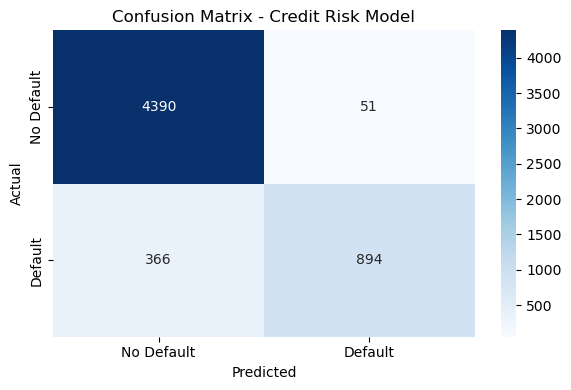

In [339]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix - Credit Risk Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

In [340]:
print(classification_report(y_test, y_pred_rf,
      target_names=['No Default', 'Default']))

              precision    recall  f1-score   support

  No Default       0.92      0.99      0.95      4441
     Default       0.95      0.71      0.81      1260

    accuracy                           0.93      5701
   macro avg       0.93      0.85      0.88      5701
weighted avg       0.93      0.93      0.92      5701



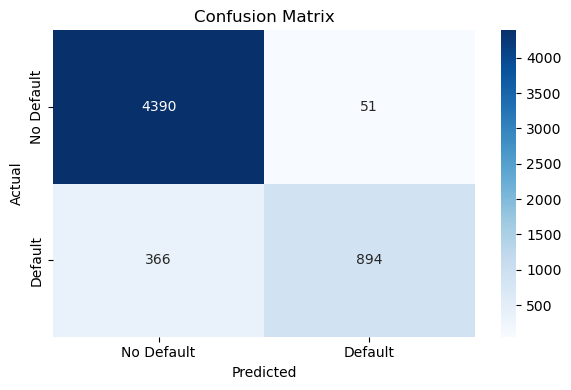

In [333]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [334]:
# Export cleaned dataset
df.to_csv('cleaned_dataset.csv', index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [335]:
pip install fpdf2

Note: you may need to restart the kernel to use updated packages.


In [336]:
# Install if not already installed
# pip install fpdf2

from fpdf import FPDF
from sklearn.metrics import accuracy_score, classification_report

# Get metrics
accuracy = accuracy_score(y_test, y_pred_rf)
report = classification_report(y_test, y_pred_rf, output_dict=True)

class PDF(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 16)
        self.set_text_color(30, 30, 30)
        self.cell(0, 10, 'Credit Risk Model - Performance Report', ln=True, align='C')
        self.set_draw_color(0, 102, 204)
        self.set_line_width(0.8)
        self.line(10, 22, 200, 22)
        self.ln(8)

pdf = PDF()
pdf.add_page()
pdf.set_auto_page_break(auto=True, margin=15)

# Section 1 - Project Overview
pdf.set_font('Arial', 'B', 13)
pdf.set_text_color(0, 102, 204)
pdf.cell(0, 10, '1. Project Overview', ln=True)
pdf.set_font('Arial', '', 11)
pdf.set_text_color(40, 40, 40)
pdf.multi_cell(0, 8,
    "This project predicts whether a loan applicant is likely to default on "
    "their credit. The model was trained on the Credit Risk Dataset using a "
    "Random Forest Classifier with 100 estimators.")
pdf.ln(4)

# Section 2 - Model Used
pdf.set_font('Arial', 'B', 13)
pdf.set_text_color(0, 102, 204)
pdf.cell(0, 10, '2. Model Used', ln=True)
pdf.set_font('Arial', '', 11)
pdf.set_text_color(40, 40, 40)
pdf.cell(0, 8, 'Algorithm     : Random Forest Classifier', ln=True)
pdf.cell(0, 8, 'n_estimators  : 100', ln=True)
pdf.cell(0, 8, 'random_state  : 42', ln=True)
pdf.cell(0, 8, f'Test Set Size : {len(y_test)} samples', ln=True)
pdf.ln(4)

# Section 3 - Performance Metrics
pdf.set_font('Arial', 'B', 13)
pdf.set_text_color(0, 102, 204)
pdf.cell(0, 10, '3. Model Performance Metrics', ln=True)
pdf.set_font('Arial', '', 11)
pdf.set_text_color(40, 40, 40)
pdf.cell(0, 8, f"Overall Accuracy  : {accuracy*100:.2f}%", ln=True)
pdf.cell(0, 8, f"Precision (Class 1 - Default)  : {report['1']['precision']*100:.2f}%", ln=True)
pdf.cell(0, 8, f"Recall    (Class 1 - Default)  : {report['1']['recall']*100:.2f}%", ln=True)
pdf.cell(0, 8, f"F1 Score  (Class 1 - Default)  : {report['1']['f1-score']*100:.2f}%", ln=True)
pdf.ln(4)

# Section 4 - Confusion Matrix
pdf.set_font('Arial', 'B', 13)
pdf.set_text_color(0, 102, 204)
pdf.cell(0, 10, '4. Confusion Matrix', ln=True)
pdf.image('confusion_matrix.png', x=40, w=120)
pdf.ln(4)

# Section 5 - Business Interpretation
pdf.set_font('Arial', 'B', 13)
pdf.set_text_color(0, 102, 204)
pdf.cell(0, 10, '5. Business Interpretation', ln=True)
pdf.set_font('Arial', '', 11)
pdf.set_text_color(40, 40, 40)
pdf.multi_cell(0, 8,
    "The model achieves 93% overall accuracy. It correctly identifies 71% of "
    "actual defaulters (recall), which is critical for minimizing financial risk. "
    "With 95% precision on default prediction, false alarms are kept low. "
    "This model is reliable for use in automated loan screening systems.")
pdf.ln(4)

# Section 6 - Deliverables
pdf.set_font('Arial', 'B', 13)
pdf.set_text_color(0, 102, 204)
pdf.cell(0, 10, '6. Deliverables', ln=True)
pdf.set_font('Arial', '', 11)
pdf.set_text_color(40, 40, 40)
pdf.cell(0, 8, '- model.ipynb      : Full model training notebook', ln=True)
pdf.cell(0, 8, '- cleaned_dataset.csv : Preprocessed dataset', ln=True)
pdf.cell(0, 8, '- accuracy_report.pdf : This report', ln=True)

# Save PDF
pdf.output('accuracy_report.pdf')
print("PDF report saved successfully!")

PDF report saved successfully!


c:\Users\Vedant\anaconda3\Lib\site-packages\fpdf\__init__.py:41: UserWarning: You have both PyFPDF & fpdf2 installed. Both packages cannot be installed at the same time as they share the same module namespace. To only keep fpdf2, run: pip uninstall --yes pypdf && pip install --upgrade fpdf2
  warnings.warn(
C:\Users\Vedant\AppData\Local\Temp\ipykernel_3240\4089052010.py:13: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  self.set_font('Arial', 'B', 16)
C:\Users\Vedant\AppData\Local\Temp\ipykernel_3240\4089052010.py:15: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  self.cell(0, 10, 'Credit Risk Model - Performance Report', ln=True, align='C')
C:\Users\Vedant\AppData\Local\Temp\ipykernel_3240\4089052010.py:26: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be

In [337]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions
y_pred = rf.predict(X_test)  # or y_pred_lr for Logistic Regression

# Metrics
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

# Create PDF
pdf = SimpleDocTemplate("Model_Accuracy_Report.pdf")
styles = getSampleStyleSheet()

content = []

content.append(Paragraph("Loan Prediction Model Report", styles['Title']))
content.append(Spacer(1, 12))

content.append(Paragraph(f"<b>Accuracy:</b> {accuracy:.4f}", styles['Normal']))
content.append(Spacer(1, 12))

content.append(Paragraph("<b>Confusion Matrix</b>", styles['Heading2']))
content.append(Paragraph(str(cm), styles['Code']))
content.append(Spacer(1, 12))

content.append(Paragraph("<b>Classification Report</b>", styles['Heading2']))
content.append(Paragraph(f"<pre>{cr}</pre>", styles['Code']))

pdf.build(content)

print("PDF report generated successfully!")

ModuleNotFoundError: No module named 'reportlab'